# Ch3: Data Modeling Using the Entity-Relationship (ER) Model

Textbook: Elmasri and Navathe, *Fundamentals of Database Systems*, 7th Edition,
Chapter 3. Read Sections 3.1-3.7 and the simple ternary example in 3.9.1.


## Teaching Summary

An ER diagram describes the objects a database represents, their properties,
and the rules connecting them. Start with a small campus example, draw one
concept at a time, and then assemble the design. The tables below are descriptions
of fictional objects and facts, not proposed relational tables or SQL output.

Ch1 introduced databases and their users. Ch2 distinguished a schema from its
current state. Here you will design a conceptual schema from stated requirements.
You need no SQL, Python, drawing application, or database installation.
Paper is enough for the drawing exercises.

By the end, you should be able to identify entities and attributes, justify keys,
read and draw relationship constraints, identify weak entities, and explain why
a three-part fact may need a ternary relationship. You should also be able to
check whether a diagram permits a state that the requirements forbid.

All campus records are synthetic. The main example covers **Fall 2026 only**.
A section is a particular class offering of a course during that term.
Separate small variants introduce rooms, cards, and mentoring; they are not
additional requirements for the final campus diagram.


## 1. From Requirements to a Diagram

An **entity-relationship (ER) model** is a high-level conceptual data model.
It describes meaning without choosing relational tables or disk structures.
A **miniworld** is the portion of the world that the database represents.

Consider two requirements: each section belongs to exactly one course, and
different courses may reuse a section number. The first requirement introduces
COURSE, SECTION, and a connection. The second asks how a section is identified.
It does not tell us how to implement that identification in SQL.

The core campus requirements are:

| Fact or rule | Meaning in this example |
|---|---|
| Students have unique StudentId values and zero or more recorded phone numbers. | Different students cannot share a StudentId. |
| Courses have unique CourseCode values. | A course can exist before any section is offered. |
| Each section belongs to exactly one course. | SectionNo is unique within its course, not across all courses. |
| Each section has exactly one instructor. | An instructor may teach zero or more sections. |
| Students may enroll in several sections. | A section may have zero or more students. |
| A grade, when available, belongs to one enrollment. | A student's different enrollments may have different grades. |
| An instructor may approve a student for a particular course. | Each approval names all three participants. |

InstructorId uniquely identifies an instructor. Approvals are recorded separately
from enrollment: these requirements do not make an approval a prerequisite for
enrollment. Repeated approval events with the same three participants are outside
this example.

**Prediction:** Which of the first two course-section requirements would be lost
if a drawing showed only two named boxes without a relationship or constraints?


### Start with facts and rules

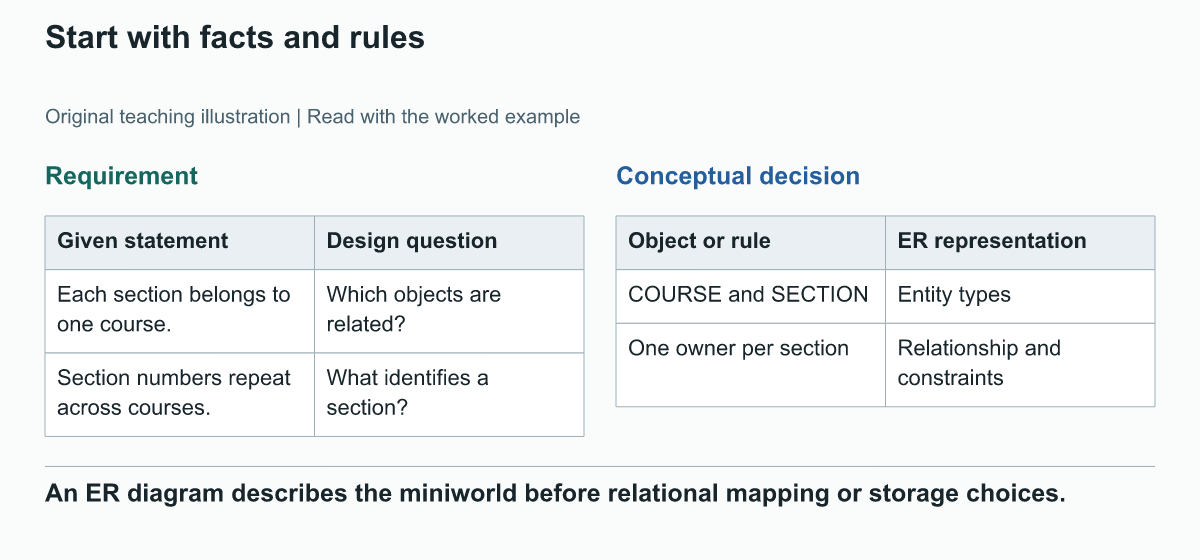

An ER diagram describes the miniworld before relational mapping or storage choices.


### Read the Diagram

The boxes alone name the types but do not express which course owns a section.
Adding a relationship states the connection. Adding constraints states how many
owners each section may have. Identification still needs a key analysis.

A requirement such as "show all sections taught by I1" is a useful design check:
the schema must preserve enough information to answer it. Choosing an index is
a later physical-design question, not an ER symbol.

**Practice:** For "each library copy belongs to one book edition," name the two
types and write one question about copy identification. Check that your question
distinguishes a copy number unique everywhere from one unique only within an edition.


## 2. Entity, Entity Type, and Entity Set

An **entity** is one distinguishable object, such as the student identified by
S101. An **entity type** describes entities with the same kinds of properties.
An **entity set** contains the entities of that type at a particular time.

STUDENT is the type. S101, S102, and S103 are three entities in its current set.
StudentId is an attribute; S101 is an attribute value used here to identify one
entity. The person is not the same thing as the identifier string.

**Prediction:** Adding S104 without changing any attribute definitions changes
the entity type, the current entity set, or both?


### One entity is not the whole entity type

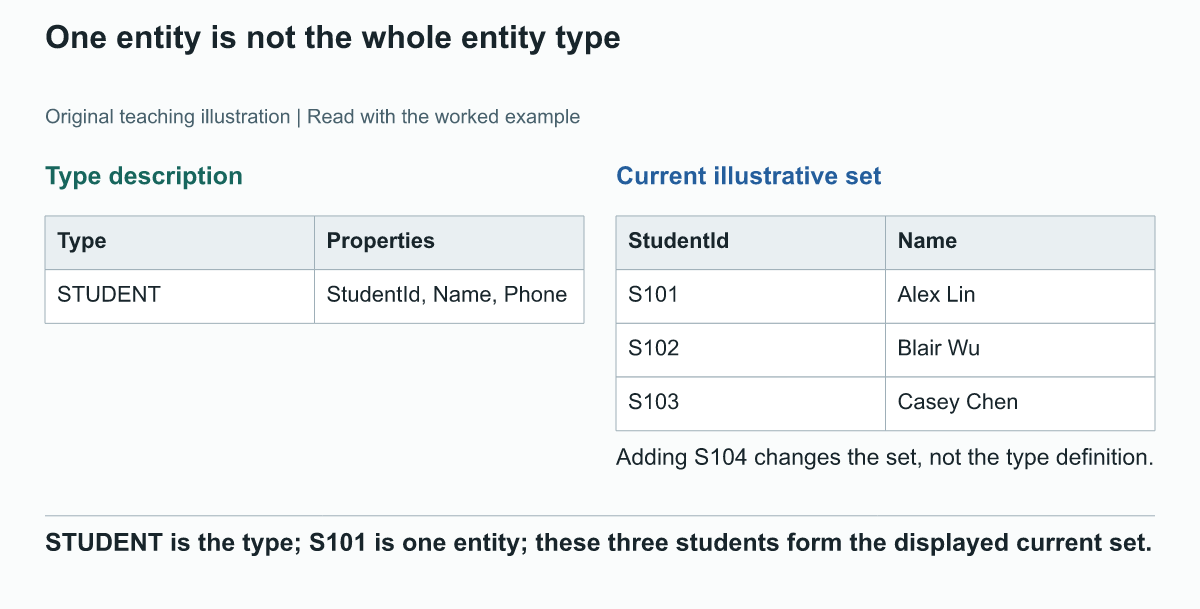

STUDENT is the type; S101 is one entity; these three students form the displayed current set.


### Read the Diagram

The displayed set grows from three students to four. The type still describes
students using the same properties. This is the Ch2 distinction between the
schema and a state, now applied to entities.

A rectangle in an ER schema names an entity type, not one particular student.
Do not draw a new schema rectangle for every row in an example.

**Practice:** Describe COURSE at all three levels: one course, the type, and a
current set of two courses. Check that the set contains objects, whereas the
type description states their shared properties.


## 3. Attributes Describe an Entity

An **attribute** describes a property of an entity. For this expanded student
profile, suppose the application needs to search given and family names
separately, keep several phone numbers, and count current enrollments.
Draw an attribute as an oval connected to its entity type. This connection
attaches the property; it is not a separate relationship type.

| Student | GivenName | FamilyName | Recorded Phone values | EnrollmentCount |
|---|---|---|---|---:|
| S101 | Alex | Lin | 02-0000-0101; 02-0000-0102 | 2 |
| S102 | Blair | Wu | 02-0000-0201 | 1 |
| S103 | Casey | Chen | None recorded | 0 |

The phone strings are invented. Semicolons separate values for reading;
they are not a recommendation to store a list in one SQL column.

A **simple attribute** has no components used by this model. A **composite
attribute** groups meaningful components: Name contains GivenName and FamilyName.
Name need not be composite in every application; that choice depends on the
information the application needs.

A **single-valued attribute** has one value for an entity when known.
A **multivalued attribute** may have several values for one entity.
Phone is multivalued here. Composite and multivalued describe different properties.
For example, an optional Contact attribute could contain several
(Label, PhoneNumber) pairs. Each pair has components, and a student can have
several pairs. This is a small example of a **complex attribute**.

A **stored attribute** supplies a recorded value. A **derived attribute** is
calculated from other information. EnrollmentCount is derived by counting the
student's enrollment relationships; it is not the sum of grade values.

**Prediction:** Which attribute needs a double oval, and which needs a dashed
oval? How many phone values does S101 have?


### Different attribute properties use different symbols

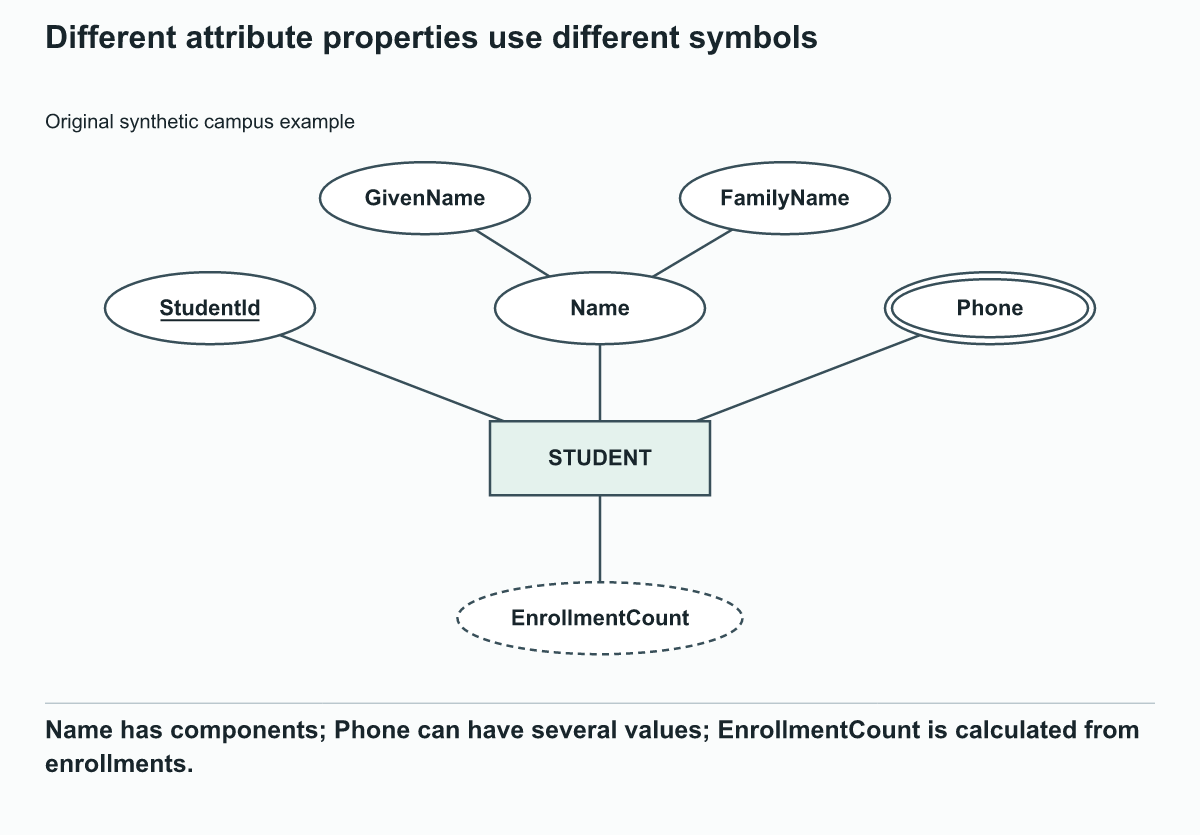

Name has components; Phone can have several values; EnrollmentCount is calculated from enrollments.


### Read the Diagram

Phone has a double oval because S101 may have more than one phone value.
EnrollmentCount has a dashed oval because it is calculated. Name connects to
two component ovals. StudentId is underlined because it is a key, discussed next.

Count S101's two enrollment facts in Section 6: the derived value is 2.
If one enrollment is removed, this count becomes 1. Its value depends on the
current relationship set, not on the number of phones.

**Practice:** Draw Contact for two invented (Label, PhoneNumber) pairs.
Then change the requirements so that only one phone may be recorded per student.
Check which multiplicity symbol changes; composite structure and multiplicity
must not be treated as the same property. This profile is an explanatory variant;
the final core diagram retains only StudentId and Phone.


## 4. Keys Identify Entities

A **key attribute** has a value that uniquely identifies every entity in each
legal state of the entity set. A key can be composite. Its components must be
needed together; adding an unnecessary component does not produce a minimal key.

Uniqueness in a few sample records is not enough to establish a key.
Two students may have different names today, but the requirements allow future
students to share a name. StudentId is a key because the rule requires uniqueness.

For a separate campus-room example, assume a room number is unique only within
its building:

| Building | RoomNo |
|---|---:|
| A | 101 |
| A | 102 |
| B | 101 |

**Prediction:** Does RoomNo alone identify a room? Does Building alone?
Which combination distinguishes all rooms under the stated rule?


### One composite key is not two separate keys

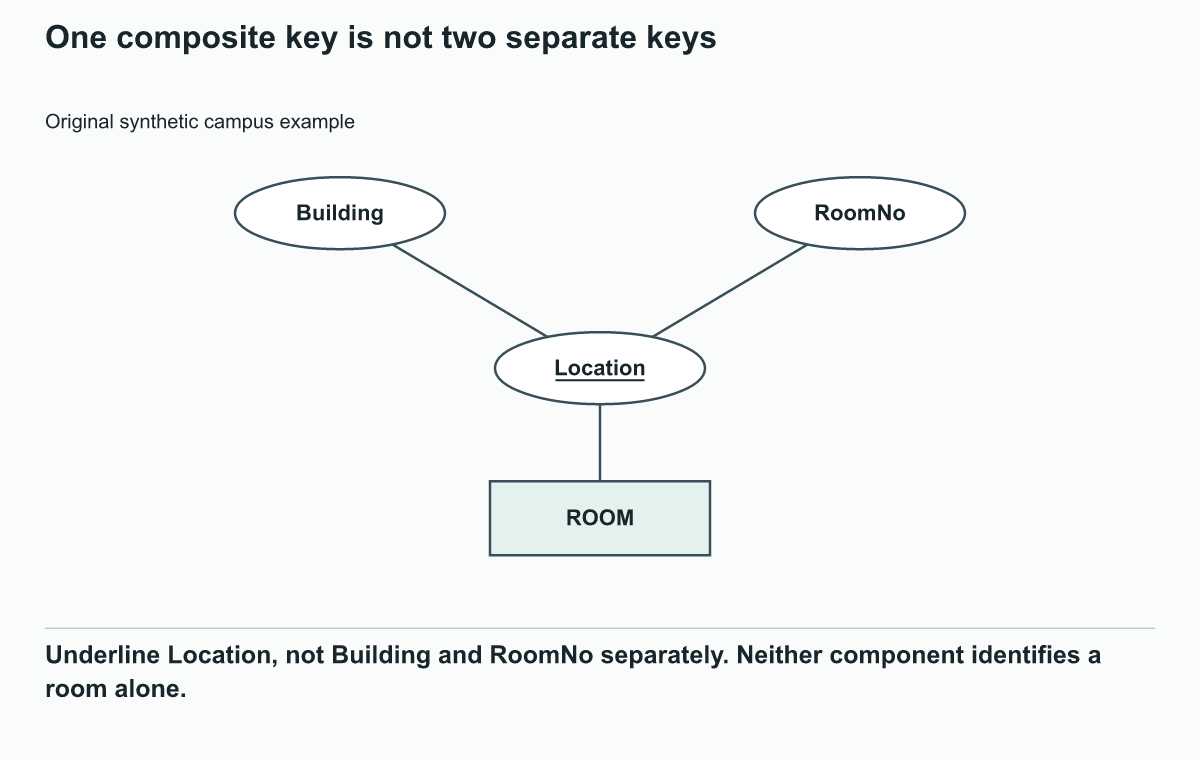

Underline Location, not Building and RoomNo separately. Neither component identifies a room alone.


### Read the Diagram

RoomNo 101 occurs twice; Building A also occurs twice. The composite
Location(Building, RoomNo) identifies a room, and removing either component
loses that guarantee. Underline the composite Location oval.

In the book's ER notation, separately underlining Building and RoomNo would
claim that each is a key independently. That would be wrong here.
An entity type may have more than one independent key if the requirements
guarantee each. This ER presentation does not select a "primary key";
that choice belongs to the relational model and mapping chapters.

**Practice:** Suppose rooms receive a new RoomId unique across all buildings,
while the Location rule remains. Draw both valid keys. Check that you have not
turned two independent keys into one larger composite key.


## 5. Domains and Missing Values

A **value set**, or **domain**, specifies allowed values of an attribute.
It is not simply the values currently present.

For an expanded COURSE description, assume Credits must be a whole number
from 1 through 6. The two observed courses currently have 2 and 3 credits.
A proposed value of 5 is still legal. A value of 2.5 fails the whole-number
condition, and 7 exceeds the limit. These are example rules, not university policy.

Missing information also needs a meaning. The book uses **NULL** for information
that is unknown or not applicable. A grade may be unknown because marking is
unfinished. In a separate staff profile, ParkingPermitNo may be inapplicable
because the person has no permit. Not knowing whether a permit exists is
different from knowing that none exists.

**Prediction:** Is 5 rejected because it is absent from today's sample?
Can an unrecorded grade automatically be interpreted as zero?


### Allowed values are not just the observed values

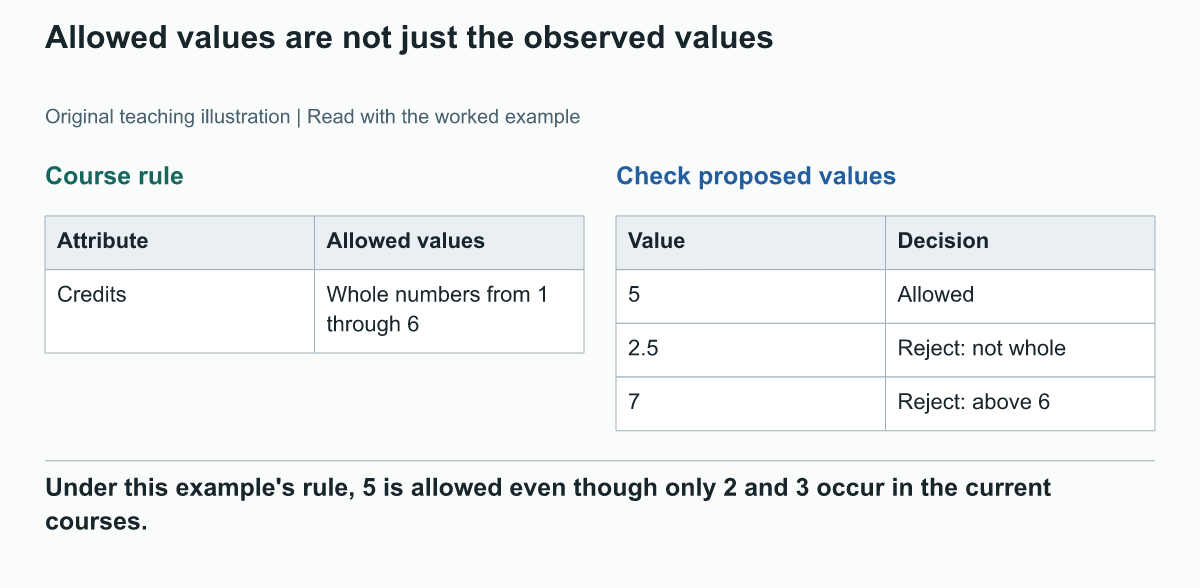

Under this example's rule, 5 is allowed even though only 2 and 3 occur in the current courses.


### Read the Diagram

Five satisfies the declared domain. The displayed rejected values violate
specific conditions, not merely an observed pattern. An unrecorded grade is
not evidence of a score of zero.

"No phone recorded" likewise does not prove that a student owns no phone.
A conceptual explanation can distinguish reasons for missing information.
The later SQL chapter will discuss what SQL NULL operations actually do.

**Practice:** Check proposed Credits values 1, 6, 0, and 3.5 against both
conditions. For an absent advisor name, write two different possible reasons
and one question that distinguishes them. Keep the reason separate from a
claim about how a DBMS stores it.


## 6. Relationships Connect Entities

A **relationship instance** associates particular participating entities.
An enrollment connecting S101 to the section DB101 / 1 is one instance.
**ENROLLS_IN** is the relationship type; its current **relationship set**
contains the enrollment instances currently recorded.
Draw a relationship type as a diamond connected to its participating entity
types. These lines are undirected connections, not a sequence of actions.

The slash notation DB101 / 1 identifies a section by course and section number
for human reading. It is not a foreign-key declaration. Section 12 explains
why this identity needs both parts.

| Student | Section | Grade |
|---|---|---:|
| S101 | DB101 / 1 | 80 |
| S101 | CS102 / 1 | 90 |
| S102 | DB101 / 1 | 70 |

The **degree** counts participating roles. This relationship is binary because
each enrollment connects a student and a section. The number of attributes
or the number of current enrollment facts does not determine its degree.

**Prediction:** How many enrollment instances are shown? How many involve S101?
Does S103's absence mean that S103 must be deleted from STUDENT?


### An enrollment connects a student to a section

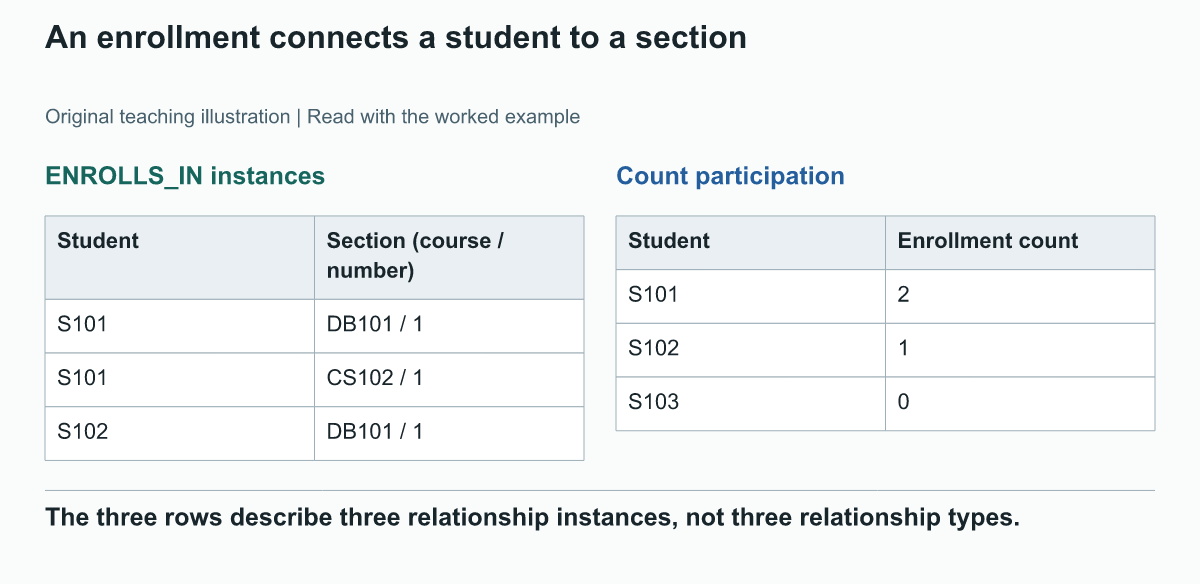

The three rows describe three relationship instances, not three relationship types.


### Read the Diagram

There are three enrollment instances; two involve S101 and none involves S103.
The requirements allow students with no enrollment, so S103 may remain.
The relationship set is separate from the entity set.

**Practice:** Add an enrollment linking S103 to DB101 / 2, with the grade not
yet known. Recount instances and each student's participation. Check that you
added a relationship instance, not a new student entity or relationship type.


## 7. Maximum Cardinality

The **cardinality ratio** of a binary relationship restricts its maximum
participation pattern. Read the requirements in both directions.

| Relationship | Rule for one object on the left | Rule for one object on the right |
|---|---|---|
| STUDENT HOLDS CARD, a separate variant | At most one card | At most one student |
| INSTRUCTOR TEACHES SECTION | May teach several sections | At most one instructor |
| STUDENT ENROLLS_IN SECTION | May enroll in several sections | May contain several students |

These give 1:1, 1:N, and M:N respectively. M and N mean that the diagram gives
no fixed numeric upper bound on that side; they do not require every entity
to participate many times.

**Prediction:** I1 teaches DB101 / 1 and DB101 / 2. Which maximum rule would
be violated if I2 also taught DB101 / 1 in this example?


### Compare maximum counts in both directions

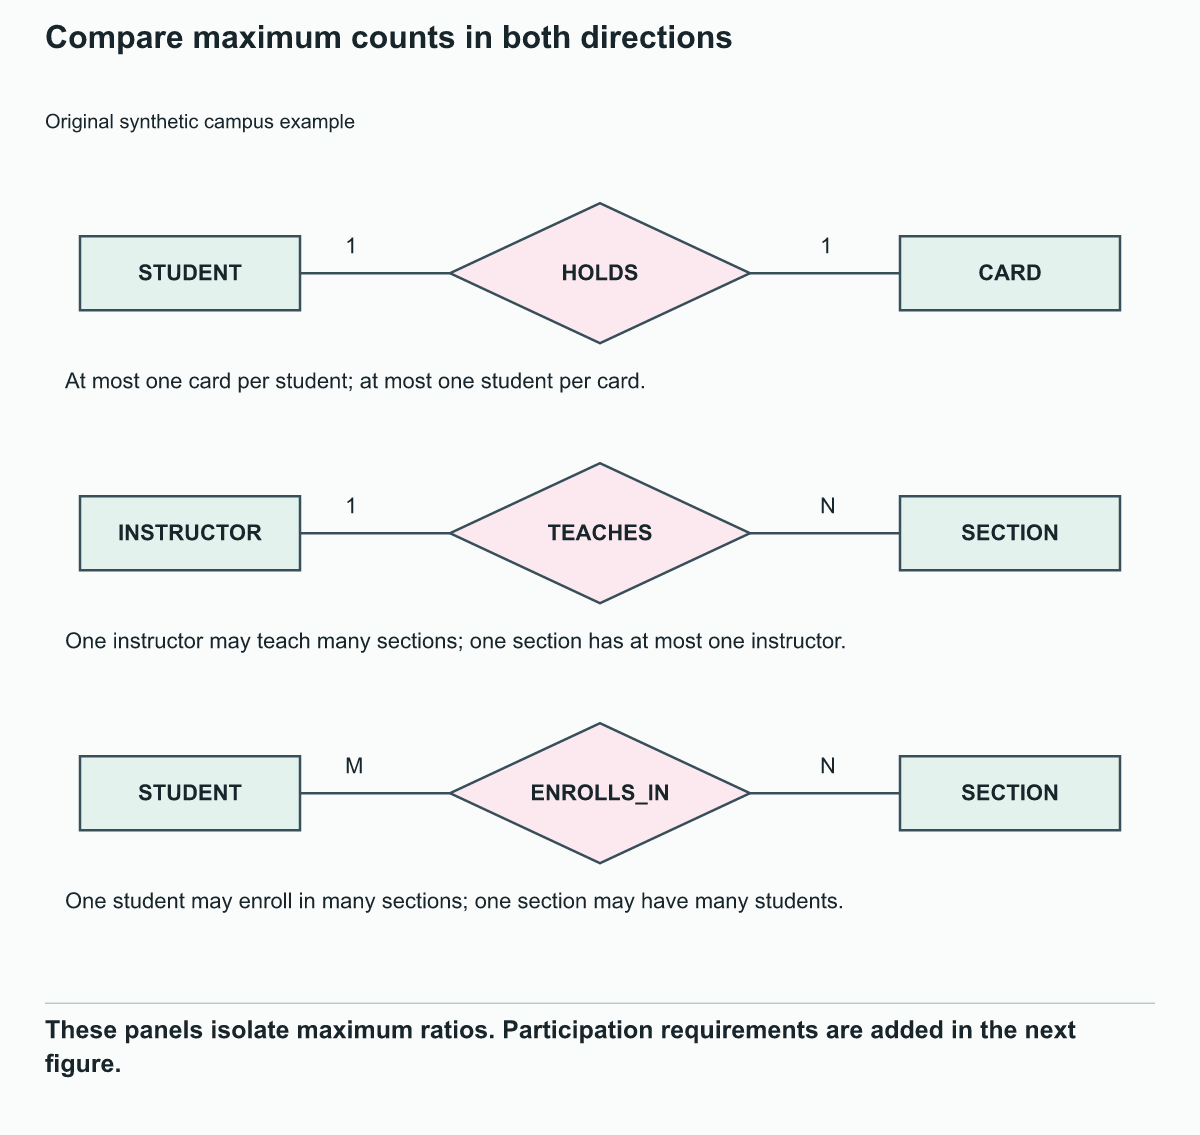

These panels isolate maximum ratios. Participation requirements are added in the next figure.


### Read the Diagram

One section would have two instructors, violating its maximum of one.
I1 teaching two sections does not violate the rule.

In the book's maximum-ratio notation, the 1 near INSTRUCTOR means that one
SECTION has at most one instructor. The N near SECTION permits an instructor
to teach many sections. Follow the whole relationship rather than reading the
nearest numeral as that entity's own participation count. Section 9 introduces
a different placement convention.

The three panels isolate the maximum counts. Participation requirements are
added next. Relationship close-ups omit keys and weak-entity markings until
Section 12 explains identification; Section 15 combines the symbols.
A small state with one instructor and one section does not prove
the relationship is 1:1; permitted future states matter.

**Practice:** For a team-teaching variant, allow several instructors per section
while each instructor may still teach several sections. Redraw only the maximum
ratio. Check your drawing using two instructors connected to the same section.


## 8. Total and Partial Participation

A **participation constraint** specifies whether every entity must participate.
**Total participation** requires at least one relationship instance for each
entity of the participating type. **Partial participation** permits zero.

The final TEACHES rule is stronger than "at most one": each section must have
exactly one instructor. SECTION therefore has total participation.
INSTRUCTOR has partial participation because an instructor can teach no section.

**Prediction:** Is a new instructor I3 with no teaching assignment allowed?
Is a new section with no instructor allowed?


### A double line requires participation

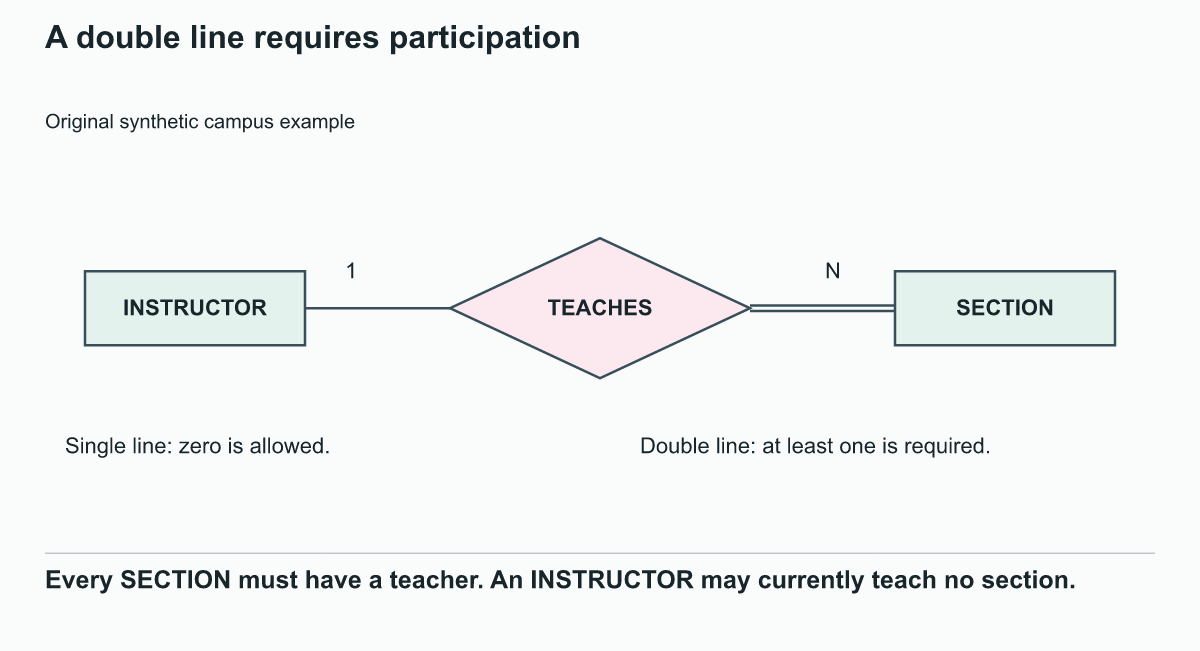

Every SECTION must have a teacher. An INSTRUCTOR may currently teach no section.


### Read the Diagram

I3 is allowed; the unassigned section is not. The double line from SECTION
to TEACHES expresses the minimum of one. The maximum ratio supplies the
upper bound of one instructor per section. These are different constraints.

Partial participation does not require an unassigned instructor to exist in
every current state. It merely permits one. Total participation does not by
itself make an entity weak: a CARD with its own globally unique CardNo can
require an owner without depending on the owner's key for identification.

**Practice:** Change the rule to require every instructor to teach at least
one section, without changing the maximum counts. Mark the line that changes.
Then decide whether adding I3 alone would still be legal and cite the new rule.


## 9. Read Min-Max Labels Carefully

The book also presents **(min, max)** notation. A pair beside an entity type
counts how many relationship instances **one entity of that type** participates in.

For TEACHES, put (0,N) beside INSTRUCTOR and (1,1) beside SECTION.
This represents the same requirements as the preceding complete TEACHES diagram.
The pair supplies both minimum and maximum, so this figure uses single
connection lines instead of the earlier single/double participation convention.

**Prediction:** Does (1,1) beside SECTION mean one student per section or
one TEACHES instance per section?


### Place this notation beside the entity being counted

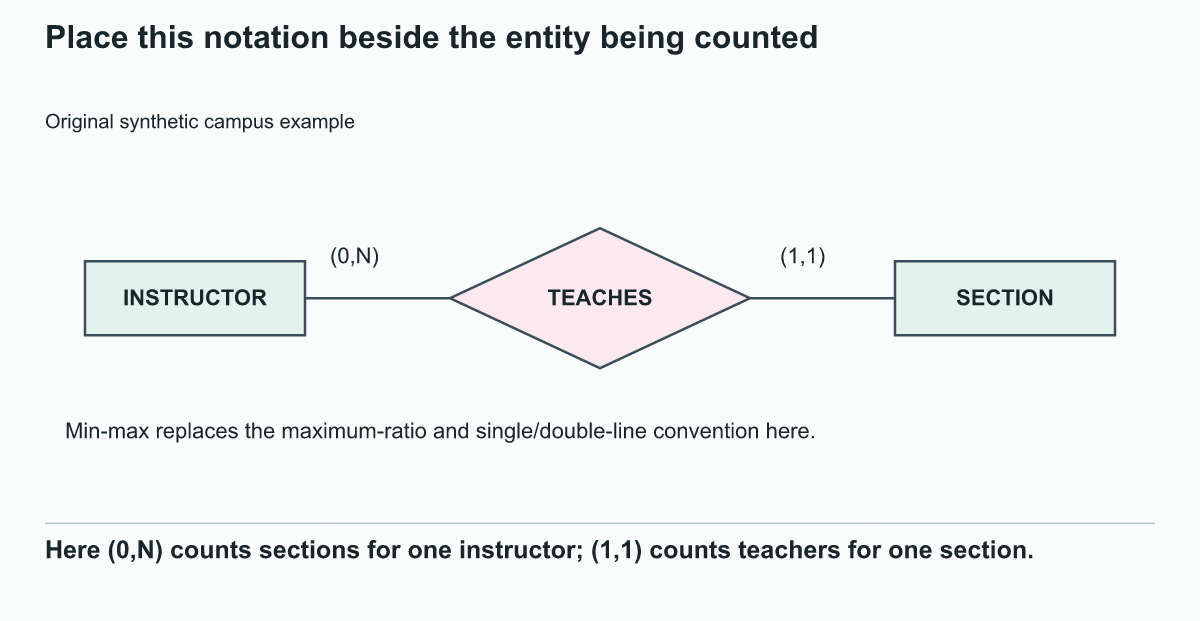

Here (0,N) counts sections for one instructor; (1,1) counts teachers for one section.


### Read the Diagram

It means exactly one TEACHES instance per section: one instructor.
It says nothing about ENROLLS_IN or the number of students.

Do not copy the positions of 1 and N from the maximum-ratio diagram into
min-max pairs. The two notations place their counts differently.
UML also has its own placement convention; do not silently mix it into this ER diagram.

**Practice:** An instructor must teach at least one and at most three sections.
Write the new pair beside INSTRUCTOR and test counts 0, 1, 3, and 4.
Keep SECTION's rule unchanged. Your check should name both accepted and rejected counts.


## 10. Recursive Relationships and Roles

A **recursive relationship** connects entities of the same type in different
**roles**. For a separate mentoring variant, one student may mentor several
students, and a student may have at most one mentor. Both roles permit zero.

| Mentor | Mentee |
|---|---|
| S101 | S102 |
| S101 | S103 |

MENTORS is binary even though only one entity-type rectangle is needed.
Each instance has a mentor participation and a mentee participation.

**Prediction:** Could the same two names in reversed order describe a different
mentoring fact? Which role has two participations in this sample?


### One entity type can participate twice

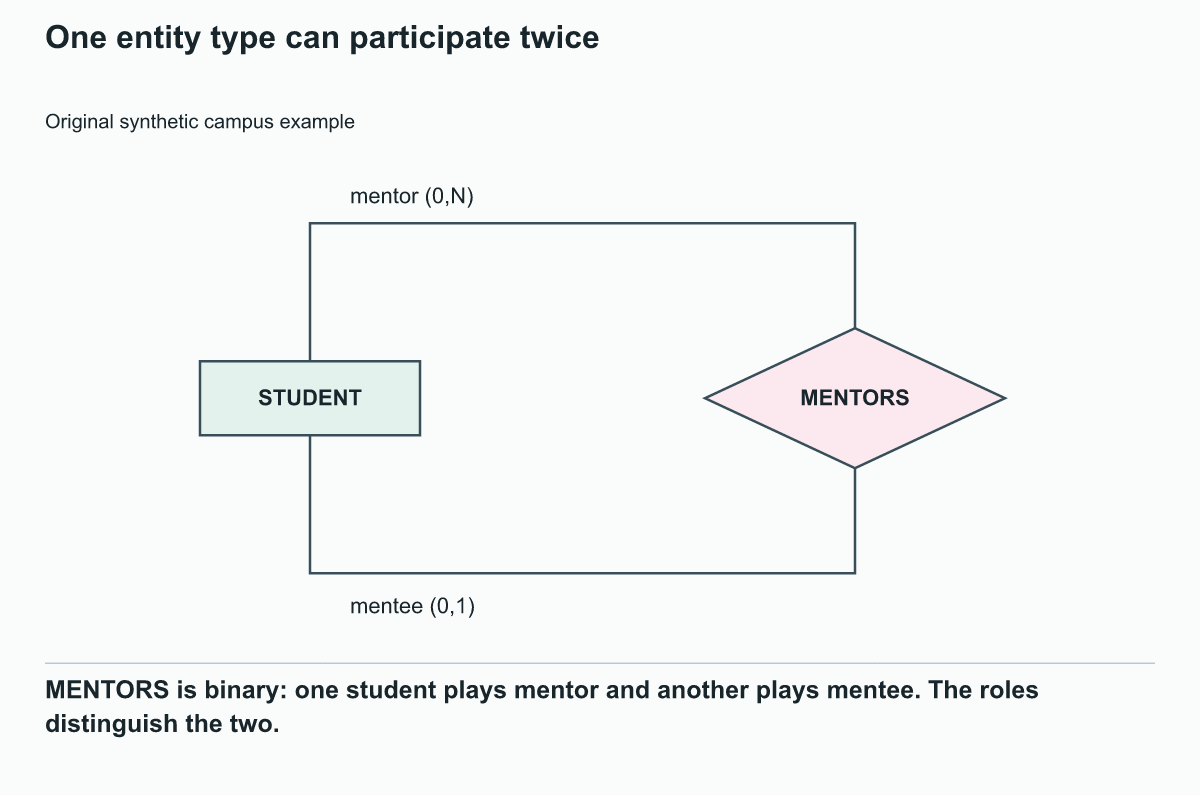

MENTORS is binary: one student plays mentor and another plays mentee. The roles distinguish the two.


### Read the Diagram

S101 is the mentor in two instances. Reversing the names reverses the roles;
S102 mentoring S101 is not the same fact as S101 mentoring S102.
The two lines connect the same type to different roles of the same relationship,
not two different student types.

If the application forbids self-mentoring or cycles, write those as additional
rules. The displayed min-max constraints alone do not prohibit either.

**Practice:** Add S102 as mentor of S103 and inspect S103's mentee participation
count. Separately consider S101 mentoring S101. Identify which question can be
answered by the displayed counts and which needs an additional business rule.


## 11. Attributes of a Relationship

An attribute can describe a relationship instance rather than one participating
entity. Grade belongs to an enrollment: it needs both the student and the section.

| Student | Section | Grade |
|---|---|---:|
| S101 | DB101 / 1 | 80 |
| S101 | CS102 / 1 | 90 |
| S102 | DB101 / 1 | 70 |

**Prediction:** Can one Grade value attached to S101 represent both of S101's
grades? Can one Grade attached to DB101 / 1 represent both of that section's grades?


### A grade belongs to a particular enrollment

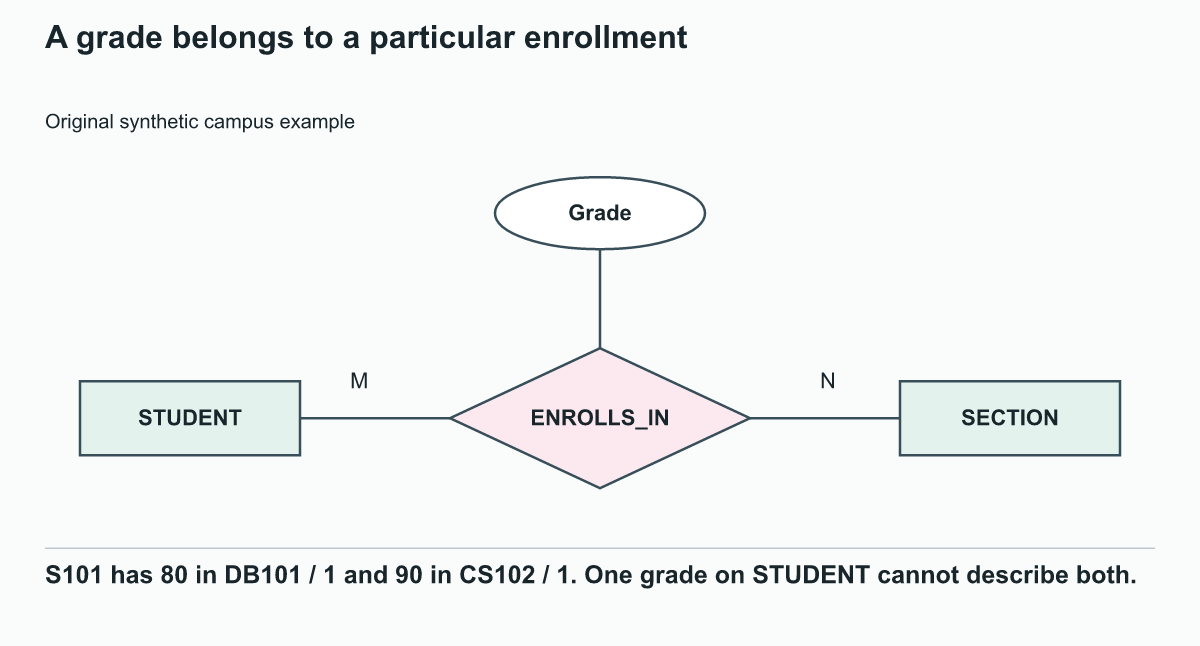

S101 has 80 in DB101 / 1 and 90 in CS102 / 1. One grade on STUDENT cannot describe both.


### Read the Diagram

Neither single value is enough. S101 has 80 and 90; DB101 / 1 has grades
80 and 70 for different students. The Grade oval connects to ENROLLS_IN.

The argument depends on these M:N facts. It does not establish that every
relationship attribute must always remain on a relationship: under suitable
1:N or 1:1 constraints, an attribute can be placed on an entity without losing
which relationship instance it describes.

**Practice:** Suppose each enrollment records a submission status, such as
"submitted" or "not submitted." Place the attribute and construct two facts
showing why attaching it to STUDENT alone could lose information.
Check that your two facts involve the same student and different sections.


## 12. Weak Entities and Partial Keys

A **weak entity type** lacks a complete identifying key of its own.
An **owner entity type** supplies part of its identification through an
**identifying relationship**. A **partial key** distinguishes weak entities
belonging to the same owner.

For this one-term example, SECTION has no globally unique SectionId:

| Owning COURSE | SectionNo | Section identified |
|---|---:|---|
| DB101 | 1 | DB101 / 1 |
| DB101 | 2 | DB101 / 2 |
| CS102 | 1 | CS102 / 1 |

**Prediction:** Are the two occurrences of SectionNo 1 an error?
Would a second section numbered 1 under DB101 be allowed?


### A section needs its owner to be identified

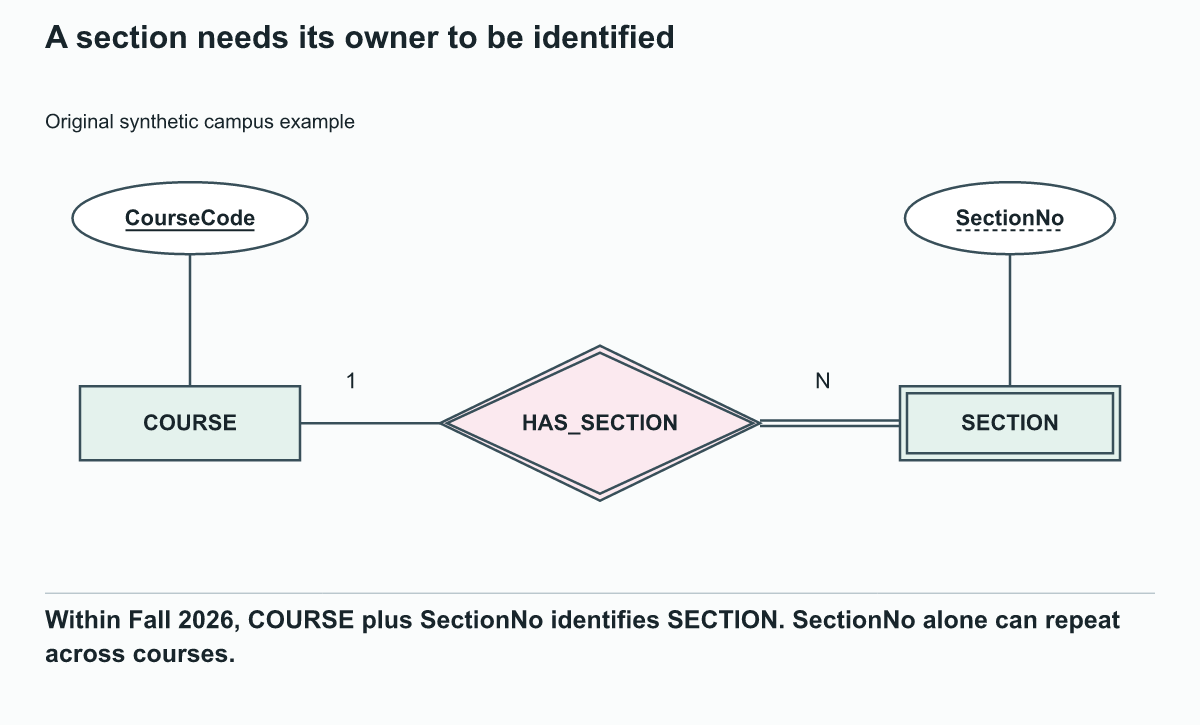

Within Fall 2026, COURSE plus SectionNo identifies SECTION. SectionNo alone can repeat across courses.


### Read the Diagram

SectionNo 1 is allowed under different courses. A second such section under
DB101 would not be distinguishable by the declared identity.
COURSE is the owner; SectionNo is the partial key.

The weak type uses a double rectangle. HAS_SECTION uses a double diamond.
The partial key has a dashed underline. SECTION participates totally in its
identifying relationship because it cannot be identified without an owner.

Existence dependence alone is insufficient: an object with its own complete
key need not be weak even when it must have an owner.
If we later keep several terms, (course, section number) may no longer distinguish
all sections. The term must enter the identification, or the requirements must
provide another complete identifier. The current example deliberately keeps one term.

**Practice:** Add CS102 / 2 and then propose a second DB101 / 2.
Explain the different outcomes. Next propose a globally unique SectionId and
identify which weak-entity symbols would no longer describe that revised choice.
Do not create relational tables yet.


## 13. Refine a Design from Its Requirements

Design is iterative. An initial list may describe "teacher name" as a section
attribute. If the application also needs instructor identity, name, and teaching
assignments, an explicit INSTRUCTOR type and TEACHES relationship describe those
facts more clearly.

First identify instructors independently. Then associate each section with its
instructor. Keep Name on INSTRUCTOR rather than repeating it as the identity
of the teacher for every section.

**Prediction:** Do two sections with teacher name Morgan prove that the same
instructor teaches both?


### Replace an entity reference with a relationship

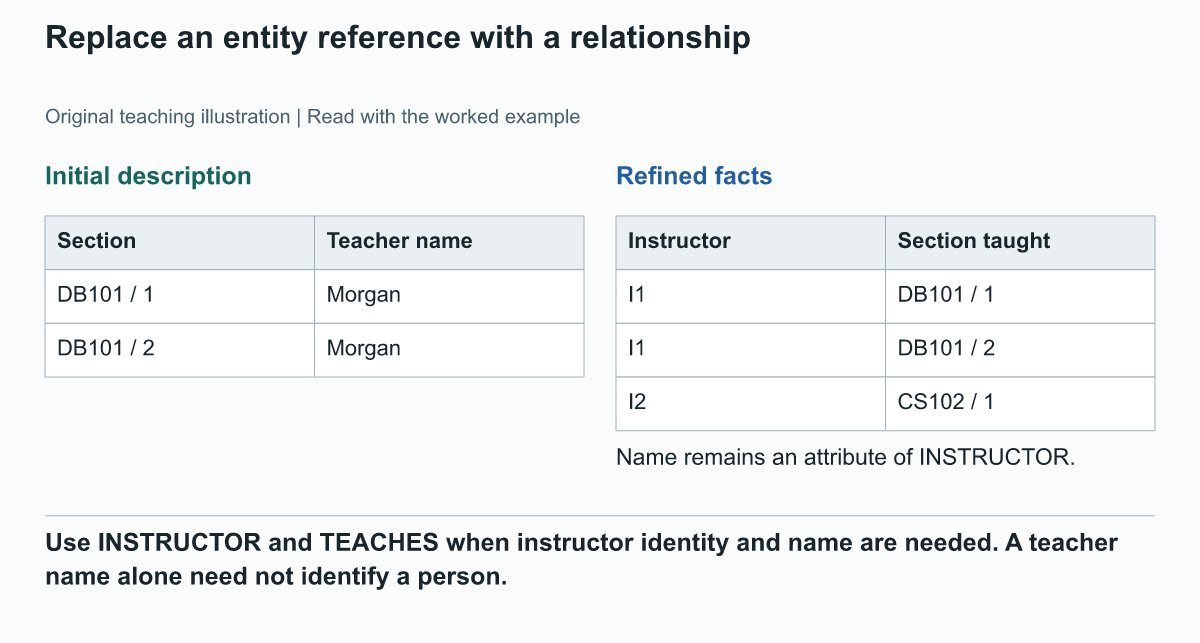

Use INSTRUCTOR and TEACHES when instructor identity and name are needed. A teacher name alone need not identify a person.


### Read the Diagram

No. Name equality is not a guaranteed identity rule. The refined example explicitly
assigns I1 to both DB101 sections; I2 teaches CS102 / 1. Those assignments, not
the repeated name alone, establish who teaches what.

Use singular nouns for types, descriptive verbs for relationships, and role names
where needed. A noun in a requirement is a candidate for analysis, not an automatic
entity type. A location may remain an attribute if only its label is needed;
it may need its own type when independent room facts and relationships matter.

Do not invent a minimum from an incomplete statement such as "instructors teach
sections." Ask whether instructors may teach none and whether a section must
already have an instructor.

**Practice:** For "each course has a room," write two unanswered design questions
about sections and room sharing. Then state the extra information that would
justify treating ROOM as an entity rather than a simple label.


## 14. A Fact That Needs Three Participants

A **ternary relationship** has three participating roles. APPROVES records that
a particular instructor approved a particular student for a particular course.

The complete recorded approval set is:

| Record | Student | Instructor | Course |
|---:|---|---|---|
| 1 | S101 | I1 | DB101 |
| 2 | S101 | I2 | CS102 |
| 3 | S102 | I1 | CS102 |

Do not assume approval merely means that the instructor has met the student or
knows the course. Those would be different facts.

**Prediction:** The pairs S101-I1, S101-CS102, and I1-CS102 each occur somewhere
in the records. Does that prove approval (S101, I1, CS102) is recorded?


### One approval names a student, instructor, and course

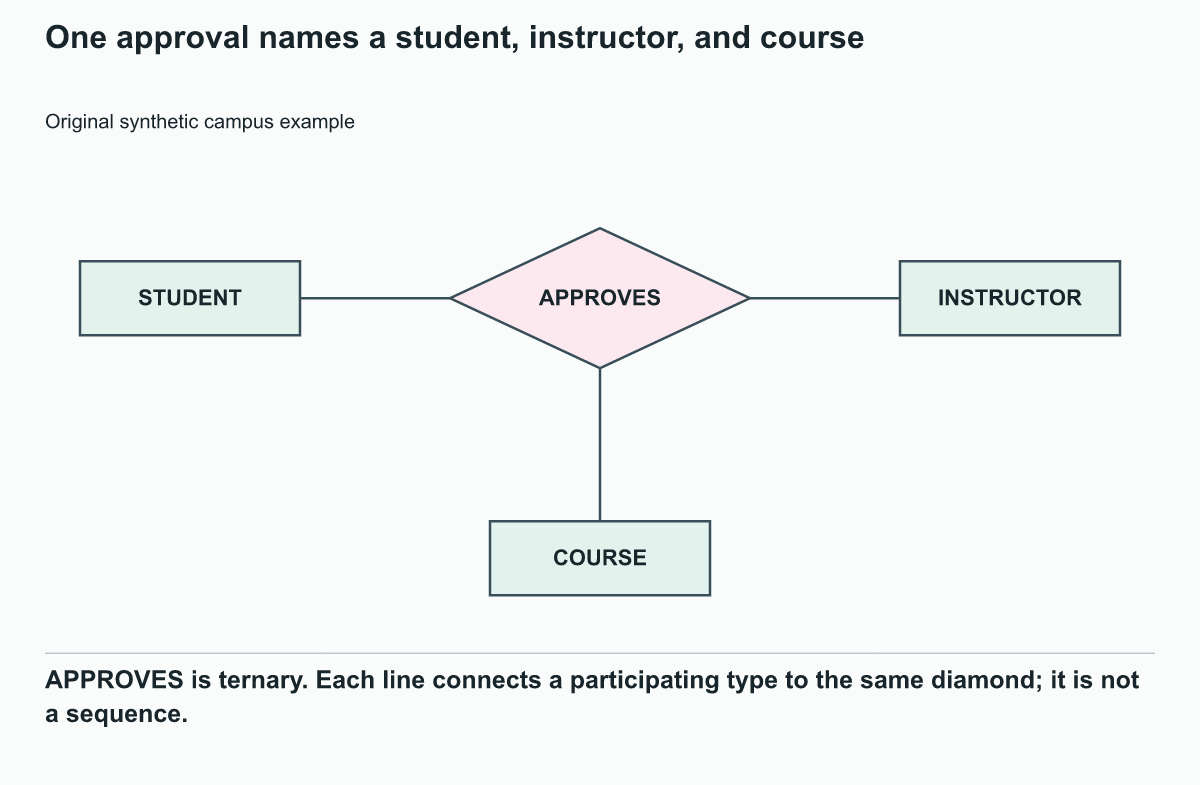

APPROVES is ternary. Each line connects a participating type to the same diamond; it is not a sequence.


### Three pairwise facts do not prove a three-way fact

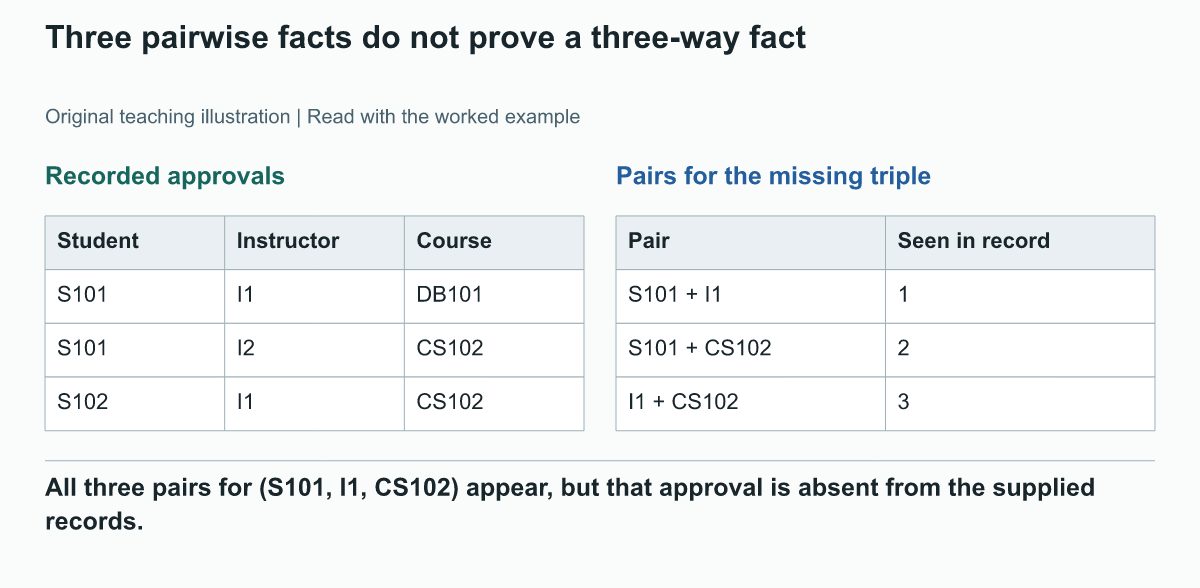

All three pairs for (S101, I1, CS102) appear, but that approval is absent from the supplied records.


### Read the Diagrams

Record 1 supplies S101-I1. Record 2 supplies S101-CS102.
Record 3 supplies I1-CS102. No record supplies all three together.
Joining the three pairwise observations in your reasoning can therefore suggest
a fact missing from the original set.

This counterexample shows why these pairs are insufficient for this case.
It does not claim that ternary relationships can never be represented another
way: additional constraints or a different conceptual representation may allow it.

The diamond has three undirected connections. It describes a simultaneous fact,
not a flow from student to instructor to course. Repeated approvals for the same
triple at different times would require an extended model.

**Practice:** Add exactly the missing approval to the complete recorded set.
Check whether any new pairwise combination appears. Compare the two full sets
to explain what the pairwise information cannot distinguish. No SQL join syntax
is needed for this reasoning.


## 15. Assemble the Campus Diagram

Build the core diagram in this order:

1. Draw STUDENT, INSTRUCTOR, COURSE, and weak SECTION.
2. Add their keys, the partial key of SECTION, and STUDENT's multivalued Phone.
3. Connect COURSE and SECTION with identifying HAS_SECTION.
4. Connect INSTRUCTOR and SECTION with TEACHES.
5. Connect STUDENT and SECTION with ENROLLS_IN, then add Grade to the relationship.
6. Connect STUDENT, INSTRUCTOR, and COURSE to the single APPROVES diamond.
7. Check each binary relationship's maximum counts and participation separately.

This is the deliberately small **core** model from Section 1. The expanded
profile, room, card, and mentoring examples illustrate other concepts; they
are not silently added to the core requirements.

**Prediction:** Which two relationships require total participation by SECTION?
Does the total-participation line in either one require every student to enroll?


### The core campus ER schema for Fall 2026

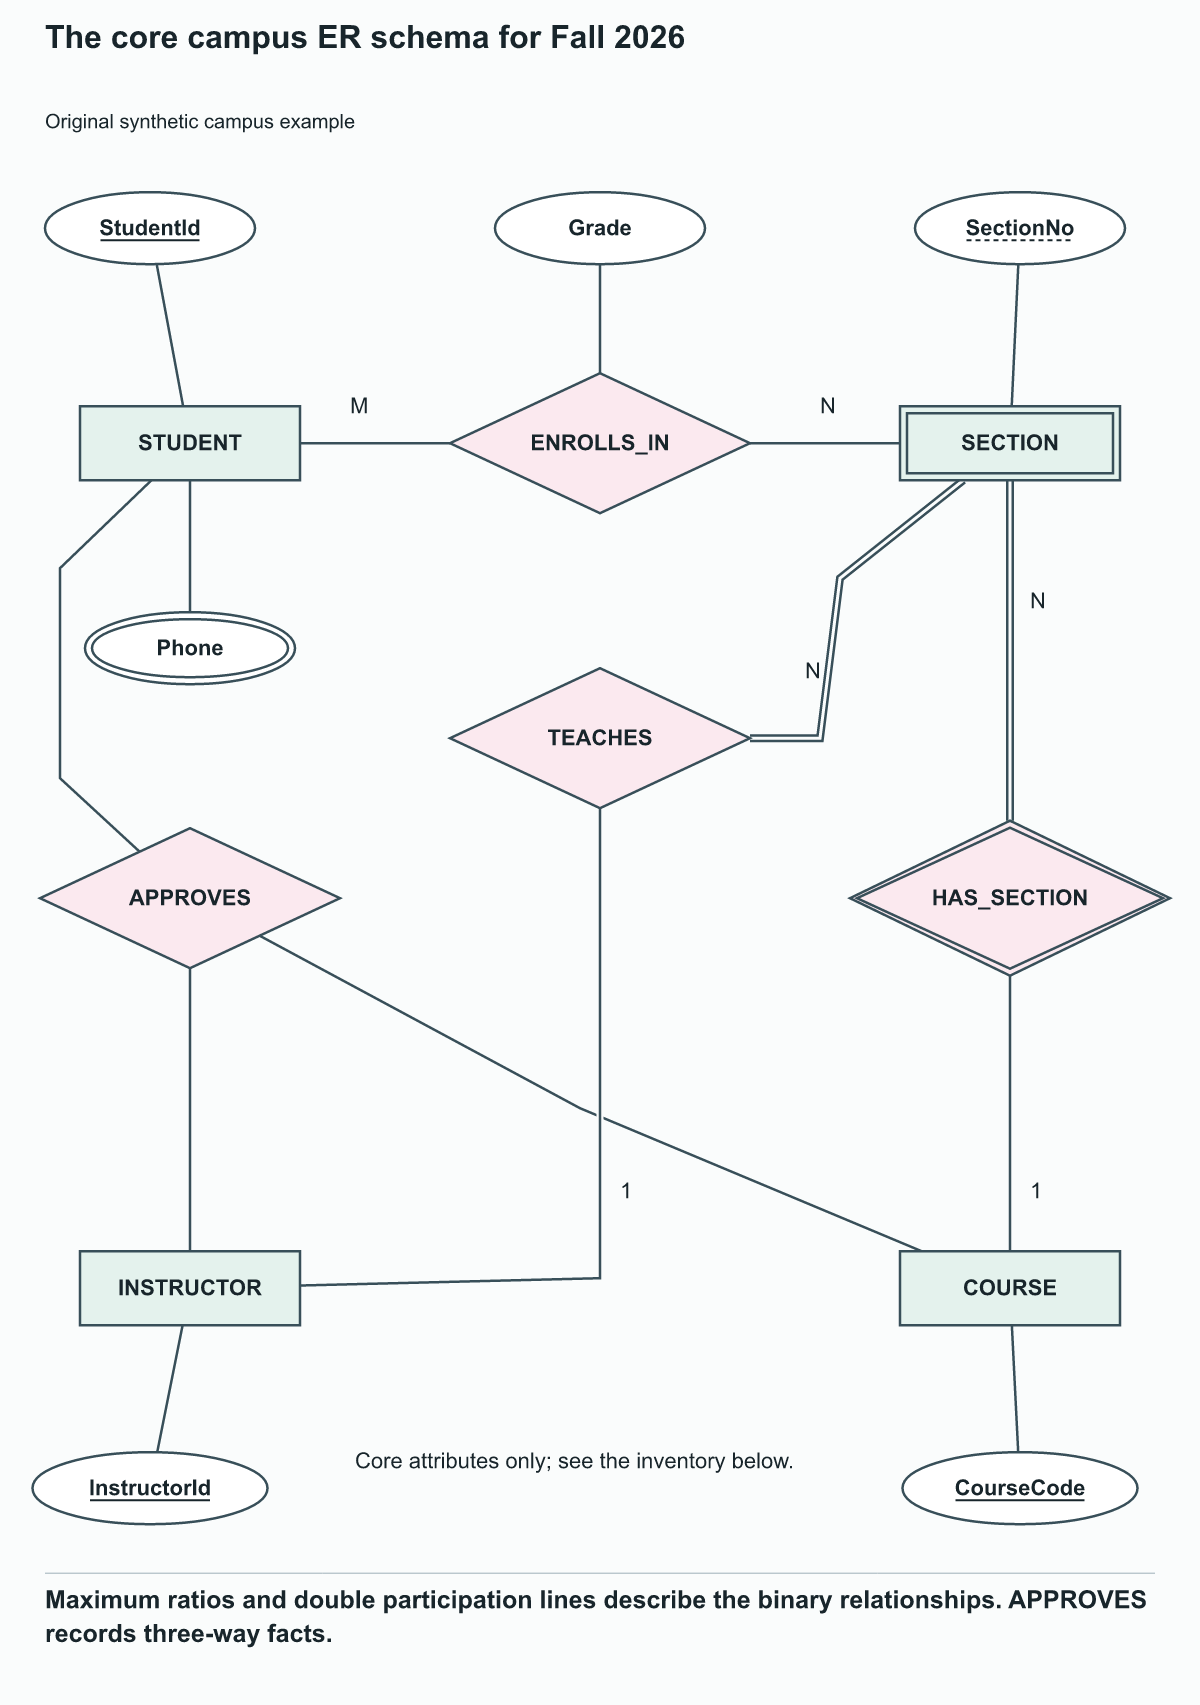

Maximum ratios and double participation lines describe the binary relationships. APPROVES records three-way facts.


### Read the Diagram

SECTION participates totally in HAS_SECTION and TEACHES: it must have both
an owner course and an instructor. Those constraints do not apply to STUDENT's
participation in ENROLLS_IN. S103 may still have no enrollment.

Here the diagram returns to maximum ratios and single/double participation
lines, not the alternative min-max convention. Bent lines have the same meaning
as straight ones. A line crossing is not a relationship or a junction; only
named endpoints define participation.

The complete core attribute inventory is intentionally small:

| Type or relationship | Attributes in the core |
|---|---|
| STUDENT | StudentId, Phone (multivalued) |
| INSTRUCTOR | InstructorId |
| COURSE | CourseCode |
| SECTION | SectionNo (partial key) |
| ENROLLS_IN | Grade, unknown until available |

Read this diagram as a schema for possible legal states, not as a picture of
only today's sample records. The sample data demonstrate consequences; they
do not establish the requirements.

**Practice:** Redraw the diagram from Section 1 without looking at the figure.
For each binary relationship, write two sentences, one from each participating
type's point of view. Test an empty course, an unassigned section, a student with
no enrollment, and two students sharing one section. Cite the exact requirement
for each decision. Retain the ternary approval fact as a three-part fact.


## 16. Compare Designs and Practice

Use the same requirements for every group's design:

- A section belongs to exactly one course.
- SectionNo is unique only within its course.
- A section has exactly one instructor; an instructor may teach none or several.
- A student may enroll in none or several sections.
- A section may have none or several students.

Each group draws COURSE, SECTION, INSTRUCTOR, and STUDENT with these relationships
and constraints, and explains its identification choice. Compare the same facts,
not artistic style or the number of colors used. A diagram may use either of
the two taught constraint notations if it uses that notation consistently.

After the group responses are fixed, compare the anonymously displayed responses
individually. For each response, test DB101 / 1 alongside CS102 / 1, an instructor
with no assignment, and a section with two instructors. Use those checks to
explain your ordering of the responses. The instructor will discuss the technical
reasons before you revise your own drawing. Peer ranking does not determine grades.

Keep your own drawing and one checked prediction as learning notes. Include one
prediction, the observed result, and either your correction or an explanation
of why your prediction was correct. Submit only the work the instructor assigns.

For further individual practice, change one requirement at a time:

| Change | What to inspect |
|---|---|
| Team teaching is allowed. | The maximum instructor count per section |
| Every student must enroll somewhere. | The minimum participation of STUDENT in ENROLLS_IN |
| Several terms must be retained. | Whether the current section identity still distinguishes all sections |
| One globally unique SectionId is supplied. | Whether identification still depends on the owner |

Do not treat a permitted state as a required state, and do not change unrelated
rules to make a proposed diagram work.


## Chapter Summary and Next Chapter

An entity type describes objects; an entity set records the objects currently
present. Attributes describe properties. Keys identify entities under rules
that apply to all legal states.

Relationships connect participating entities. Maximum cardinality and minimum
participation answer different questions. A relationship attribute describes
a particular connection. A weak entity needs its owner's identity, and a ternary
fact may contain information lost by considering pairs alone.

Ch4 adds the **Enhanced Entity-Relationship (EER) model**. It will ask how a
general type and more specialized types can share properties, and how membership
rules should be represented. Keep this campus model for that discussion.
Relational mapping and SQL implementation come later; they are not prerequisites
for completing this chapter's drawings.


## Textbook Reading

The explanations and examples use original wording and synthetic data.
The conceptual definitions follow Chapter 3 of the prescribed book.

| Material here | Textbook sections and printed pages |
|---|---|
| Requirements and conceptual design | 3.1-3.2, pp.60-63 |
| Entities, attributes, keys, domains | 3.3, pp.63-72 |
| Relationships, roles, constraints, relationship attributes | 3.4, pp.72-78 |
| Weak entities | 3.5, p.79 |
| Refinement, ER symbols, min-max notation | 3.6-3.7, pp.80-85 |
| Simple ternary relationship | 3.9.1, pp.88-91 |

The chapter does not assign detailed UML notation, advanced higher-degree
constraints, or the book's full additional UNIVERSITY design.
